# 🦜🔗 LangChain — Complete Revision Notebook
> **Rakesh's Production-Grade AI Engineering Guide**  
> Covers: Core Concepts → Chains → Agents → RAG → Memory → Deployment  
> Stack: LangChain + LangGraph + LangSmith + Vector DBs + FastAPI

---

## 📋 Table of Contents
| # | Topic | Category |
|---|-------|----------|
| 1 | Installation & Setup | Basics |
| 2 | LLM Initialization (ChatOpenAI) | Core |
| 3 | Simple Prompt & Predict | Core |
| 4 | PromptTemplate | Core |
| 5 | LLMChain | Chains |
| 6 | Sequential Chains | Chains |
| 7 | Conversation Memory (Full) | Memory |
| 8 | Chat History Memory (Window) | Memory |
| 9 | Embeddings | Vectors |
| 10 | Vector Database (FAISS) | Vectors |
| 11 | Document Loaders (PDF, Web, CSV) | RAG |
| 12 | Text Splitter | RAG |
| 13 | Full RAG Pipeline | RAG |
| 14 | Retriever | RAG |
| 15 | RetrievalQA Chain | RAG |
| 16 | Output Parser | Output |
| 17 | Tool Calling | Agents |
| 18 | Agents (ReAct) | Agents |
| 19 | Python REPL Tool | Agents |
| 20 | Search Tool (DuckDuckGo) | Agents |
| 21 | Streaming Responses | Advanced |
| 22 | Async Execution | Advanced |
| 23 | LangSmith Tracing | Observability |
| 24 | LangGraph — Stateful Agents | LangGraph |
| 25 | LCEL (LangChain Expression Language) | Advanced |
| 26 | FastAPI Deployment | Production |
| 27 | Interview Cheat Sheet | Interview Prep |


---
## ⚙️ SECTION 1: Installation & Environment Setup

In [ ]:
# ✅ Install all required packages
!pip install langchain langchain-openai langchain-community
!pip install faiss-cpu tiktoken pypdf
!pip install langsmith langchain-core
!pip install duckduckgo-search
!pip install python-dotenv

In [ ]:
# ✅ Environment Setup (Best Practice: Use .env file, never hardcode keys)
import os
from dotenv import load_dotenv

load_dotenv()  # loads from .env file

# .env file should contain:
# OPENAI_API_KEY=sk-...
# LANGCHAIN_API_KEY=ls__...
# LANGCHAIN_PROJECT=my-project

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

# 🎯 Interview Tip: Always use environment variables. 
# In production: AWS Secrets Manager / GCP Secret Manager / Azure Key Vault

---
## 🤖 SECTION 2: LLM Initialization

**Theory:** LangChain wraps different LLM providers under a common interface.  
**Why it matters:** You can swap OpenAI → Anthropic → Ollama without changing your pipeline logic.

> 🎯 **Interview Tip:** Explain the abstraction layer — LangChain decouples your app logic from the LLM provider.

In [ ]:
from langchain_openai import ChatOpenAI

# Standard Initialization
llm = ChatOpenAI(
    model="gpt-4",
    temperature=0,         # 0 = deterministic, 1 = creative
    max_tokens=1000,
    openai_api_key=OPENAI_API_KEY
)

print("✅ LLM Initialized:", llm.model_name)

# 💡 Production Note:
# temperature=0 → factual tasks (Q&A, classification)
# temperature=0.7-1 → creative tasks (story gen, brainstorming)

# 🔄 Swap to local Ollama model (free, no API key):
# from langchain_community.llms import Ollama
# llm = Ollama(model="llama3")

---
## 📝 SECTION 3: Simple Prompt & Predict

**Theory:** The most basic way to interact with an LLM — send a string, get a string back.

In [ ]:
from langchain_core.messages import HumanMessage, SystemMessage

# Method 1: Direct invoke
response = llm.invoke("Explain RAG in 2 sentences")
print(response.content)

# Method 2: With system + human messages (Production way)
messages = [
    SystemMessage(content="You are an expert ML engineer. Be concise."),
    HumanMessage(content="What is LangChain?")
]
response = llm.invoke(messages)
print(response.content)

# 🎯 Interview Tip: 
# SystemMessage sets the persona/behavior
# HumanMessage is the user input
# AIMessage is model output
# These map directly to ChatML format used by OpenAI

---
## 📐 SECTION 4: PromptTemplate

**Theory:** PromptTemplates allow you to create reusable, parameterized prompts.  
**Why it matters:** In production, you never hardcode prompts. Templates make prompts testable, versioned, and reusable.

> 🎯 **Interview Tip:** PromptTemplate is to prompts what Jinja2 is to HTML templates.

In [ ]:
from langchain.prompts import PromptTemplate, ChatPromptTemplate

# --- Basic PromptTemplate ---
prompt = PromptTemplate(
    input_variables=["topic", "level"],
    template="Explain {topic} to a {level} level student in simple terms."
)

# Format it
formatted = prompt.format(topic="Transformers", level="beginner")
print("Formatted Prompt:\n", formatted)

# --- ChatPromptTemplate (for Chat Models — Production Standard) ---
chat_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a {role}. Always respond in {language}."),
    ("human", "{question}")
])

formatted_chat = chat_prompt.format_messages(
    role="senior ML engineer",
    language="English",
    question="What is attention mechanism?"
)
print("\nChat Prompt:\n", formatted_chat)

# 💡 Production Note:
# Store prompts in separate .py or .yaml files
# Version them in LangSmith Hub for team collaboration

---
## ⛓️ SECTION 5: LLMChain

**Theory:** LLMChain = PromptTemplate + LLM. It's the fundamental building block of all LangChain applications.

> ⚠️ **Note:** LLMChain is the legacy way. Modern LangChain uses **LCEL (|)** — covered in Section 25.

In [ ]:
from langchain.chains import LLMChain
from langchain.prompts import PromptTemplate

# Legacy LLMChain
prompt = PromptTemplate(
    input_variables=["product"],
    template="Write a one-line tagline for a product called {product}."
)

chain = LLMChain(llm=llm, prompt=prompt)
result = chain.invoke({"product": "AI-powered Resume Builder"})
print("Legacy LLMChain Result:", result["text"])

# ✅ Modern LCEL way (preferred)
modern_chain = prompt | llm
result = modern_chain.invoke({"product": "AI-powered Resume Builder"})
print("\nModern LCEL Result:", result.content)

# 🎯 Interview Tip:
# LLMChain is deprecated in newer LangChain versions
# LCEL (pipe operator |) is the new standard
# LCEL supports streaming, async, and batching natively

---
## 🔗 SECTION 6: Sequential Chains

**Theory:** Multiple chains connected in series — output of Chain1 becomes input of Chain2.  
**Real Use Case:** Blog Generator → SEO Optimizer → Social Media Caption Generator

In [ ]:
from langchain.prompts import PromptTemplate

# Step 1: Generate a blog title
title_prompt = PromptTemplate(
    input_variables=["topic"],
    template="Generate a compelling blog title about: {topic}"
)

# Step 2: Write intro based on title
intro_prompt = PromptTemplate(
    input_variables=["title"],
    template="Write a 3-sentence intro paragraph for a blog titled: {title}"
)

# Step 3: Create tweet from intro
tweet_prompt = PromptTemplate(
    input_variables=["intro"],
    template="Convert this blog intro into a Twitter thread starter (max 280 chars): {intro}"
)

# LCEL Sequential Pipeline
from langchain_core.output_parsers import StrOutputParser

parser = StrOutputParser()

chain1 = title_prompt | llm | parser
chain2 = intro_prompt | llm | parser
chain3 = tweet_prompt | llm | parser

# Full pipeline
from langchain_core.runnables import RunnablePassthrough

full_pipeline = (
    {"topic": RunnablePassthrough()}
    | title_prompt | llm | parser
    | (lambda title: {"title": title})
    | intro_prompt | llm | parser
)

result = full_pipeline.invoke("Agentic AI in 2025")
print("Pipeline Output:\n", result)

# 🎯 Interview Tip:
# This is a multi-step reasoning pipeline
# In production: add error handling between each step
# LangSmith will trace each step automatically

---
## 🧠 SECTION 7: Conversation Memory (Full Buffer)

**Theory:** By default, LLMs are stateless. Memory modules inject past context into each new call.  
**Types of Memory:**
- `ConversationBufferMemory` — stores full history
- `ConversationBufferWindowMemory` — stores last K exchanges
- `ConversationSummaryMemory` — LLM summarizes old conversations
- `ConversationSummaryBufferMemory` — hybrid (recent = full, old = summary)

> 🎯 **Interview Tip:** Discuss trade-offs — buffer memory has token limit issues. Summary memory loses details. Summary+Buffer is production sweet spot.

In [ ]:
from langchain.memory import (
    ConversationBufferMemory,
    ConversationSummaryMemory,
    ConversationSummaryBufferMemory
)
from langchain.chains import ConversationChain

# --- Type 1: Full Buffer Memory ---
memory_full = ConversationBufferMemory()
conv_chain = ConversationChain(llm=llm, memory=memory_full, verbose=True)

conv_chain.predict(input="Hi! I'm Rakesh, an ML Engineer.")
conv_chain.predict(input="What is my name?")

print("Full Memory:")
print(memory_full.chat_memory.messages)

print("\n" + "="*50 + "\n")

# --- Type 2: Summary Memory (for long conversations) ---
memory_summary = ConversationSummaryMemory(llm=llm)
conv_chain_summary = ConversationChain(llm=llm, memory=memory_summary)

conv_chain_summary.predict(input="I am building a RAG-based chatbot for a hospital.")
conv_chain_summary.predict(input="The chatbot should answer patient queries from medical PDFs.")

print("Summary Memory:")
print(memory_summary.buffer)

# 💡 Production: Use Redis or PostgreSQL to persist memory across sessions
# from langchain.memory import RedisChatMessageHistory

---
## 🪟 SECTION 8: Window Memory

**Theory:** Keeps only the last K conversation turns in context. Prevents token overflow for long chats.

> 🎯 **Interview Tip:** This is used in production chatbots where full context is too expensive. K=5 typically covers enough context.

In [ ]:
from langchain.memory import ConversationBufferWindowMemory
from langchain.chains import ConversationChain

# K=3 means only last 3 human-AI exchanges are kept
memory_window = ConversationBufferWindowMemory(k=3)

conv = ConversationChain(llm=llm, memory=memory_window)

conversations = [
    "My name is Rakesh.",
    "I work at CGI.",
    "I am studying for ML interviews.",
    "What is my name?",  # Should remember — within last 3
]

for msg in conversations:
    response = conv.predict(input=msg)
    print(f"Human: {msg}")
    print(f"AI: {response}\n")

print("Current Memory Window:")
print(memory_window.chat_memory.messages)

---
## 🔢 SECTION 9: Embeddings

**Theory:** Embeddings convert text → dense numerical vectors that capture semantic meaning.  
**Why it matters:** Foundation of all semantic search, RAG, and similarity tasks.  

> 🎯 **Interview Tip:** Know that OpenAI `text-embedding-ada-002` produces 1536-dim vectors. Cosine similarity is used to compare embeddings. Dimension matters for storage & speed.

In [ ]:
from langchain_openai import OpenAIEmbeddings
import numpy as np

embeddings_model = OpenAIEmbeddings(model="text-embedding-ada-002")

# Embed single text
text = "LangChain is a framework for building LLM applications"
embedding = embeddings_model.embed_query(text)
print(f"Embedding Dimensions: {len(embedding)}")
print(f"First 5 values: {embedding[:5]}")

# Embed multiple documents
docs = [
    "RAG combines retrieval with generation",
    "LangGraph builds stateful multi-agent systems",
    "Vector databases store embeddings efficiently"
]
doc_embeddings = embeddings_model.embed_documents(docs)
print(f"\nNumber of doc embeddings: {len(doc_embeddings)}")

# Manual cosine similarity check
from numpy.linalg import norm

def cosine_sim(a, b):
    return np.dot(a, b) / (norm(a) * norm(b))

query_emb = embeddings_model.embed_query("What is RAG?")
for i, doc in enumerate(docs):
    sim = cosine_sim(query_emb, doc_embeddings[i])
    print(f"Similarity with '{doc[:40]}...': {sim:.4f}")

# 💡 Free Alternative:
# from langchain_community.embeddings import HuggingFaceEmbeddings
# embeddings_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

---
## 🗄️ SECTION 10: Vector Database (FAISS)

**Theory:** Vector DBs store and index embeddings for fast similarity search (ANN - Approximate Nearest Neighbors).  
**Popular Vector DBs:**
| DB | Type | Best For |
|-----|------|----------|
| FAISS | Local/In-memory | Prototyping, small datasets |
| Pinecone | Managed cloud | Production, serverless |
| Chroma | Local/embedded | Dev, open source |
| Weaviate | Self-hosted/cloud | Hybrid search |
| Qdrant | Self-hosted/cloud | High performance |

> 🎯 **Interview Tip:** Know ANN algorithms — HNSW (Hierarchical NSW), IVF (Inverted File Index). FAISS uses both. Pinecone uses HNSW internally.

In [ ]:
from langchain.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain.schema import Document

embeddings = OpenAIEmbeddings()

# Create sample documents
documents = [
    Document(page_content="LangChain enables building LLM-powered applications", metadata={"source": "docs", "page": 1}),
    Document(page_content="RAG retrieves relevant documents before generating answers", metadata={"source": "docs", "page": 2}),
    Document(page_content="LangGraph is used for building multi-agent systems", metadata={"source": "docs", "page": 3}),
    Document(page_content="Vector databases store embeddings for similarity search", metadata={"source": "docs", "page": 4}),
    Document(page_content="LangSmith provides observability for LLM applications", metadata={"source": "docs", "page": 5}),
]

# Build FAISS index
vectorstore = FAISS.from_documents(documents, embeddings)

# Similarity Search
query = "How to monitor LLM apps?"
results = vectorstore.similarity_search(query, k=2)
print("Top 2 Similar Documents:")
for i, doc in enumerate(results):
    print(f"{i+1}. {doc.page_content} | Source: {doc.metadata}")

# Similarity search with scores
results_with_scores = vectorstore.similarity_search_with_score(query, k=3)
print("\nWith Scores (lower = more similar in FAISS):")
for doc, score in results_with_scores:
    print(f"Score: {score:.4f} | {doc.page_content[:60]}")

# 💾 Save and Load FAISS Index (Production)
vectorstore.save_local("faiss_index")
loaded_vs = FAISS.load_local("faiss_index", embeddings, allow_dangerous_deserialization=True)
print("\n✅ Index saved and reloaded successfully")

---
## 📄 SECTION 11: Document Loaders

**Theory:** Document Loaders ingest various file formats and convert them into LangChain `Document` objects.  
**Why it matters:** Real RAG systems need to ingest PDFs, websites, databases, Notion, etc.

> 🎯 **Interview Tip:** Know at least 5 loaders. The go-to for enterprise RAG is PDF + Web + CSV.

In [ ]:
# --- PDF Loader ---
from langchain_community.document_loaders import PyPDFLoader

# pdf_loader = PyPDFLoader("your_document.pdf")
# pdf_docs = pdf_loader.load()
# print(f"PDF Pages: {len(pdf_docs)}")
# print(f"Sample: {pdf_docs[0].page_content[:200]}")

# --- Web Loader ---
from langchain_community.document_loaders import WebBaseLoader

# web_loader = WebBaseLoader("https://python.langchain.com/docs/introduction")
# web_docs = web_loader.load()
# print(f"Web Doc Length: {len(web_docs[0].page_content)}")

# --- CSV Loader ---
from langchain_community.document_loaders import CSVLoader

# csv_loader = CSVLoader(file_path="data.csv", source_column="text_column")
# csv_docs = csv_loader.load()

# --- Directory Loader (load all files in a folder) ---
from langchain_community.document_loaders import DirectoryLoader, TextLoader

# dir_loader = DirectoryLoader('./docs', glob='**/*.txt', loader_cls=TextLoader)
# all_docs = dir_loader.load()

# 💡 Demo with synthetic docs (no file needed)
from langchain.schema import Document

sample_docs = [
    Document(
        page_content="""LangChain is a framework for developing applications powered by 
        large language models. It provides tools for chaining LLM calls, memory, agents, and RAG.""",
        metadata={"source": "langchain_docs.pdf", "page": 1}
    ),
    Document(
        page_content="""LangGraph extends LangChain to support stateful, multi-actor applications.
        It models workflows as graphs where nodes are functions and edges are transitions.""",
        metadata={"source": "langchain_docs.pdf", "page": 2}
    ),
]

print(f"Loaded {len(sample_docs)} documents")
print(f"Doc 1 source: {sample_docs[0].metadata}")

# 🎯 Other Important Loaders:
# NotionDBLoader — Load Notion pages
# S3FileLoader — Load files from AWS S3
# GitLoader — Load code from GitHub repos
# UnstructuredEmailLoader — Parse emails

---
## ✂️ SECTION 12: Text Splitter

**Theory:** LLMs have context windows. Large documents must be split into smaller chunks before embedding.  
**Key Parameters:**
- `chunk_size` — max characters/tokens per chunk
- `chunk_overlap` — overlap between chunks (prevents cutting context at boundaries)

> 🎯 **Interview Tip:** Wrong chunking = bad RAG. chunk_overlap ensures a sentence cut at chunk boundary still appears in the next chunk. Typical: chunk_size=1000, overlap=200.

In [ ]:
from langchain.text_splitter import (
    RecursiveCharacterTextSplitter,
    CharacterTextSplitter,
    TokenTextSplitter
)

# --- RecursiveCharacterTextSplitter (RECOMMENDED) ---
# Tries to split on: paragraph → sentence → word → character
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100,
    length_function=len,
    separators=["\n\n", "\n", " ", ""]
)

long_text = """LangChain is a framework for developing applications powered by language models.
It connects LLMs to external data sources and tools. The framework provides components 
for prompt templates, chains, agents, and memory.

RAG or Retrieval Augmented Generation is a technique that improves LLM responses by 
retrieving relevant context from a knowledge base before generating the final answer.
This reduces hallucination and keeps responses grounded in factual data.

LangGraph is an extension of LangChain that enables stateful, multi-agent applications.
It uses a graph-based approach where nodes represent processing steps and edges represent
the flow of data between them."""

chunks = splitter.split_text(long_text)
print(f"Total chunks created: {len(chunks)}")
for i, chunk in enumerate(chunks):
    print(f"\nChunk {i+1} (len={len(chunk)}):\n{chunk}")

# Split Document objects directly
split_docs = splitter.split_documents(sample_docs)
print(f"\nSplit {len(sample_docs)} docs → {len(split_docs)} chunks")

# 🎯 Interview Tip:
# For code: use Language splitter → preserves function/class boundaries
# from langchain.text_splitter import Language, RecursiveCharacterTextSplitter
# code_splitter = RecursiveCharacterTextSplitter.from_language(Language.PYTHON)

---
## 🔄 SECTION 13: Full RAG Pipeline

**Theory:** RAG = Retrieval Augmented Generation  
**Pipeline:** Documents → Chunk → Embed → Store in VectorDB → Query → Retrieve → Augment Prompt → Generate

```
User Query
    ↓
Embed Query
    ↓
Similarity Search in VectorDB
    ↓
Top-K Relevant Chunks
    ↓
Inject into Prompt: "Context: {chunks}\nQuestion: {query}"
    ↓
LLM Generates Answer
```

> 🎯 **Interview Tip:** RAG vs Fine-tuning — RAG = add knowledge, Fine-tuning = change behavior. For most enterprise use cases, RAG > Fine-tuning (cheaper, updatable, auditable).

In [ ]:
from langchain.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.schema import Document
from langchain.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

# STEP 1: Documents (simulated)
raw_documents = [
    Document(page_content="""LangChain is a framework for building LLM applications. 
    Key components include: Chains, Agents, Memory, Retrievers, and Output Parsers.
    It supports models from OpenAI, Anthropic, Google, and open-source via HuggingFace."""),
    Document(page_content="""RAG stands for Retrieval Augmented Generation. 
    It works by retrieving relevant documents and injecting them as context.
    RAG reduces hallucination compared to pure generation."""),
    Document(page_content="""LangGraph enables building stateful agents as directed graphs. 
    Nodes process data, edges define flow. It supports cycles, branching, and human-in-loop."""),
    Document(page_content="""LangSmith is an observability platform for LLM applications.
    It provides tracing, evaluation, debugging, and monitoring capabilities.
    Teams use it to improve prompt quality and track model performance over time."""),
]

# STEP 2: Split into chunks
splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=50)
chunks = splitter.split_documents(raw_documents)
print(f"STEP 2: Created {len(chunks)} chunks")

# STEP 3: Create embeddings & store in VectorDB
embeddings = OpenAIEmbeddings()
vectorstore = FAISS.from_documents(chunks, embeddings)
print(f"STEP 3: VectorDB built with {vectorstore.index.ntotal} vectors")

# STEP 4: Create Retriever
retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 3})

# STEP 5: RAG Prompt Template
rag_prompt = ChatPromptTemplate.from_template("""
You are a helpful AI assistant. Answer the question based ONLY on the provided context.
If the answer is not in the context, say "I don't have enough information."

Context:
{context}

Question: {question}

Answer:
""")

# STEP 6: Build LCEL RAG Chain
def format_docs(docs):
    return "\n\n".join([doc.page_content for doc in docs])

rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)

# STEP 7: Run Query
question = "How does LangSmith help LLM developers?"
response = rag_chain.invoke(question)
print(f"\nQuestion: {question}")
print(f"RAG Answer: {response}")

---
## 🔍 SECTION 14 & 15: Retriever + RetrievalQA

**Theory:** Retriever is a standard interface for fetching documents.  
**RetrievalQA** is a pre-built chain that combines Retriever + LLM for Q&A.

> 🎯 **Interview Tip:** Know retriever types — `similarity`, `mmr` (Max Marginal Relevance — for diversity), `similarity_score_threshold`.

In [ ]:
from langchain.chains import RetrievalQA
from langchain.vectorstores import FAISS

# --- Retriever Types ---

# 1. Similarity Retriever
retriever_sim = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}
)

# 2. MMR Retriever (Max Marginal Relevance — more diverse results)
retriever_mmr = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 3, "fetch_k": 10, "lambda_mult": 0.5}
)

# 3. Threshold Retriever (only retrieve if score above threshold)
retriever_thresh = vectorstore.as_retriever(
    search_type="similarity_score_threshold",
    search_kwargs={"score_threshold": 0.7}
)

# --- RetrievalQA Chain ---
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",       # stuff = inject all docs into prompt
    retriever=retriever_sim,
    return_source_documents=True,  # shows which docs were used
    verbose=True
)

result = qa_chain.invoke({"query": "What is LangSmith used for?"})
print("Answer:", result["result"])
print("\nSource Documents:")
for doc in result["source_documents"]:
    print(f"  - {doc.page_content[:100]}...")

# 🎯 chain_type options:
# 'stuff' → all docs in one prompt (simple, fast)
# 'map_reduce' → process each doc separately, then combine (for many docs)
# 'refine' → iteratively refine answer with each doc
# 'map_rerank' → rank each doc answer and pick best

---
## 📤 SECTION 16: Output Parsers

**Theory:** LLMs return raw text. Output Parsers convert that text into structured Python objects.  
**Why it matters:** Production apps need structured data — JSON, lists, Pydantic models — not raw strings.

> 🎯 **Interview Tip:** For complex structured output, use `PydanticOutputParser`. It gives you type safety and validation. Combined with `OutputFixingParser` for retry on parse failure.

In [ ]:
from langchain.output_parsers import (
    StructuredOutputParser,
    ResponseSchema,
    PydanticOutputParser,
    CommaSeparatedListOutputParser
)
from langchain_core.output_parsers import JsonOutputParser
from pydantic import BaseModel, Field
from typing import List

# --- Type 1: StructuredOutputParser ---
response_schemas = [
    ResponseSchema(name="answer", description="The answer to the user's question"),
    ResponseSchema(name="confidence", description="Confidence score from 0 to 1"),
    ResponseSchema(name="sources", description="List of sources used")
]

parser = StructuredOutputParser.from_response_schemas(response_schemas)
format_instructions = parser.get_format_instructions()

prompt = PromptTemplate(
    template="Answer the question.\n{format_instructions}\n\nQuestion: {question}",
    input_variables=["question"],
    partial_variables={"format_instructions": format_instructions}
)

chain = prompt | llm | parser
result = chain.invoke({"question": "What is RAG?"})
print("Structured Output:", result)
print("Answer field:", result["answer"])

# --- Type 2: PydanticOutputParser (Best Practice) ---
class JobAnalysis(BaseModel):
    role: str = Field(description="Job role title")
    required_skills: List[str] = Field(description="List of required technical skills")
    experience_years: int = Field(description="Years of experience required")
    salary_range: str = Field(description="Salary range if mentioned")

pydantic_parser = PydanticOutputParser(pydantic_object=JobAnalysis)

job_prompt = PromptTemplate(
    template="Extract job details from this description.\n{format_instructions}\n\nJob Description: {jd}",
    input_variables=["jd"],
    partial_variables={"format_instructions": pydantic_parser.get_format_instructions()}
)

job_chain = job_prompt | llm | pydantic_parser
jd_text = """We need a Senior ML Engineer with 5+ years experience. 
Skills: Python, PyTorch, MLOps, Docker, Kubernetes. Salary: 30-40 LPA"""

job_result = job_chain.invoke({"jd": jd_text})
print("\nPydantic Parsed Result:")
print(f"Role: {job_result.role}")
print(f"Skills: {job_result.required_skills}")
print(f"Experience: {job_result.experience_years} years")

---
## 🛠️ SECTION 17 & 18: Tool Calling + Agents

**Theory:** Agents use LLMs to decide WHICH tools to use and WHEN.  
**ReAct Pattern:** Reason → Act → Observe → Reason → Act (loop)

```
User Question
    ↓
LLM Thinks: 'I need to search for this'
    ↓
LLM Calls Tool: search('query')
    ↓
Observes: tool result
    ↓
LLM Thinks: 'Now I have the answer'
    ↓
Final Answer
```

> 🎯 **Interview Tip:** Know ReAct vs Function Calling vs OpenAI Assistants. LangChain agents use `@tool` decorator. In production, always set `max_iterations` to prevent infinite loops.

In [ ]:
from langchain.agents import AgentExecutor, create_react_agent
from langchain.tools import tool
from langchain import hub
import math

# --- Define Custom Tools ---
@tool
def calculate(expression: str) -> str:
    """Evaluate a mathematical expression. Input should be a valid Python math expression."""
    try:
        result = eval(expression, {"__builtins__": {}}, {"math": math, "sqrt": math.sqrt})
        return str(result)
    except Exception as e:
        return f"Error: {str(e)}"

@tool
def get_ml_term_definition(term: str) -> str:
    """Get the definition of a machine learning term. Input should be the ML term."""
    definitions = {
        "rag": "RAG (Retrieval Augmented Generation) combines retrieval of documents with LLM generation.",
        "fine-tuning": "Fine-tuning adapts a pretrained model to a specific task using labeled data.",
        "embeddings": "Embeddings are dense vector representations of text that capture semantic meaning.",
        "transformer": "Transformer is a deep learning architecture using self-attention mechanisms.",
    }
    return definitions.get(term.lower(), f"Definition not found for '{term}'")

@tool  
def get_current_date(query: str) -> str:
    """Get the current date and time. Input can be any string."""
    from datetime import datetime
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

tools = [calculate, get_ml_term_definition, get_current_date]

# Load ReAct prompt from LangChain Hub
# prompt = hub.pull("hwchase17/react")

# Create Agent
# agent = create_react_agent(llm, tools, prompt)
# agent_executor = AgentExecutor(
#     agent=agent,
#     tools=tools,
#     verbose=True,
#     max_iterations=5,
#     handle_parsing_errors=True
# )

# result = agent_executor.invoke({"input": "What is the square root of 144 and what does RAG mean?"})
# print(result["output"])

# Demo tool usage
print("Tool Demo:")
print("Calculator:", calculate.invoke("sqrt(144) + 10"))
print("ML Term:", get_ml_term_definition.invoke("rag"))
print("Date:", get_current_date.invoke(""))

---
## 🐍 SECTION 19: Python REPL Tool + 🌐 SECTION 20: Search Tool

In [ ]:
# --- Python REPL Tool ---
from langchain_experimental.tools import PythonREPLTool

python_repl = PythonREPLTool()

# Agent can run Python code dynamically
code = """
import pandas as pd
import numpy as np

# Create sample data
data = {'model': ['GPT-4', 'Claude', 'Gemini', 'Llama3'], 
        'accuracy': [0.92, 0.90, 0.88, 0.85]}
df = pd.DataFrame(data)
print(df.sort_values('accuracy', ascending=False).to_string())
"""
result = python_repl.run(code)
print("Python REPL Output:")
print(result)

# --- DuckDuckGo Search Tool ---
# from langchain_community.tools import DuckDuckGoSearchRun
# search = DuckDuckGoSearchRun()
# result = search.run("LangChain latest version 2024")
# print("Search Result:", result[:500])

# 🎯 Interview Tip:
# PythonREPLTool is powerful but dangerous — never expose it to untrusted users
# Use with sandboxing in production (e.g., Docker container, restricted exec)
# For safe code execution: consider using code interpreters via API

---
## ⚡ SECTION 21: Streaming Responses

**Theory:** Instead of waiting for the full response, stream tokens as they are generated.  
**Why it matters:** Much better UX for long responses. Every production chatbot (ChatGPT, Claude) uses streaming.

> 🎯 **Interview Tip:** Streaming is critical for perceived performance. Know that FastAPI uses `StreamingResponse` + `EventSourceResponse` (SSE) or WebSockets to push streamed tokens to frontend.

In [ ]:
from langchain_openai import ChatOpenAI

# Streaming LLM
llm_streaming = ChatOpenAI(
    model="gpt-4",
    temperature=0,
    streaming=True
)

# Method 1: stream() — iterate over chunks
print("Streaming output:")
for chunk in llm_streaming.stream("Explain LangChain in 3 bullet points"):
    print(chunk.content, end="", flush=True)

print("\n\n--- LCEL Stream ---")

# Method 2: LCEL chain with streaming
from langchain.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate.from_template("Write a 5-sentence blog intro about {topic}")
chain = prompt | llm_streaming | StrOutputParser()

for chunk in chain.stream({"topic": "Agentic AI"}):
    print(chunk, end="", flush=True)

# 💡 FastAPI Streaming endpoint (Production Pattern):
# @app.get("/stream")
# async def stream_response(question: str):
#     async def generate():
#         async for chunk in chain.astream({"topic": question}):
#             yield f"data: {chunk}\n\n"
#     return StreamingResponse(generate(), media_type="text/event-stream")

---
## 🔀 SECTION 22: Async Execution

**Theory:** Async allows multiple LLM calls to run concurrently instead of sequentially.  
**Why it matters:** A batch of 10 sequential calls takes 10x time. Async batching takes ~1x time.

> 🎯 **Interview Tip:** Use `asyncio.gather()` to run multiple chains in parallel. LangChain has `.ainvoke()`, `.astream()`, `.abatch()` for all async operations.

In [ ]:
import asyncio
import time
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4", temperature=0)

# --- Async Single Call ---
async def async_single():
    response = await llm.ainvoke("What is LangChain?")
    return response.content

# --- Async Batch (run multiple in parallel) ---
async def async_batch():
    topics = [
        "What is RAG?",
        "What is LangGraph?",
        "What is LangSmith?",
        "What are agents in LangChain?"
    ]
    
    # Sequential (slow)
    start = time.time()
    sequential_results = []
    # for topic in topics:
    #     r = await llm.ainvoke(topic)
    #     sequential_results.append(r)
    # print(f"Sequential: {time.time()-start:.2f}s")
    
    # Parallel (fast) — ALL calls fire simultaneously
    start = time.time()
    parallel_results = await asyncio.gather(*[llm.ainvoke(topic) for topic in topics])
    print(f"Parallel: {time.time()-start:.2f}s")
    
    for topic, result in zip(topics, parallel_results):
        print(f"Q: {topic}")
        print(f"A: {result.content[:100]}...\n")

# Run in notebook
await async_batch()

# In a script (not notebook):
# asyncio.run(async_batch())

---
## 🔭 SECTION 23: LangSmith — Observability & Tracing

**Theory:** LangSmith provides full visibility into every LLM call, chain, and agent run.  
**Features:** Tracing, Evaluation, Dataset management, Playground, Cost tracking

> 🎯 **Interview Tip:** In production, you MUST have observability. LangSmith = logging + tracing for LLMs. Just like how you'd use Datadog/Prometheus for traditional services.

In [ ]:
import os

# Enable LangSmith Tracing (just set these env vars!)
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"] = "ls__your_key_here"
os.environ["LANGCHAIN_PROJECT"] = "langchain-revision-notebook"

# That's it! Now every chain/agent run is automatically traced.

# --- Manual Tracing with @traceable ---
from langsmith import traceable

@traceable(name="my_custom_rag_pipeline", run_type="chain")
def my_rag_pipeline(question: str) -> str:
    # Your pipeline code here
    response = llm.invoke(question)
    return response.content

# result = my_rag_pipeline("What is LangChain?")

# --- Evaluation using LangSmith Datasets ---
# from langsmith import Client
# client = Client()

# Create evaluation dataset
# dataset = client.create_dataset("rag-eval-dataset")
# client.create_examples(
#     inputs=[{"question": "What is RAG?"}],
#     outputs=[{"answer": "RAG combines retrieval with generation"}],
#     dataset_id=dataset.id
# )

print("LangSmith Setup Complete")
print("Visit: https://smith.langchain.com to see traces")

# 💡 What you see in LangSmith:
# - Each LLM call with input/output
# - Token usage and cost per call
# - Latency breakdown per step
# - Error traces
# - A/B prompt comparison

---
## 🕸️ SECTION 24: LangGraph — Stateful Multi-Agent Systems

**Theory:** LangGraph models AI workflows as directed graphs (nodes + edges).  
- **Nodes** = functions/LLM calls
- **Edges** = transitions between nodes
- **State** = shared data passed through the graph

**When to use LangGraph vs LangChain:**
- LangChain: Linear workflows
- LangGraph: Branching logic, loops, multi-agent, human-in-the-loop

> 🎯 **Interview Tip:** LangGraph is the industry standard for production agents now. Know StateGraph, TypedDict for state, conditional_edges, and interrupt_before for human-in-loop.

In [ ]:
# pip install langgraph
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator

# --- Define State ---
class AgentState(TypedDict):
    messages: list
    question: str
    answer: str
    needs_search: bool
    search_results: str

# --- Define Nodes ---
def classify_question(state: AgentState) -> AgentState:
    """Decide if question needs search or can be answered directly"""
    question = state["question"]
    # Simple heuristic: questions with 'latest', 'current', 'today' need search
    needs_search = any(word in question.lower() for word in ["latest", "current", "today", "2024", "2025"])
    print(f"[Classify] Question: '{question}' → Needs Search: {needs_search}")
    return {**state, "needs_search": needs_search}

def search_web(state: AgentState) -> AgentState:
    """Simulate web search"""
    question = state["question"]
    # Simulated search result
    search_result = f"[Simulated search result for: '{question}'] Latest info: LangChain v0.3 was released with LCEL improvements."
    print(f"[Search] Found: {search_result[:80]}...")
    return {**state, "search_results": search_result}

def generate_answer(state: AgentState) -> AgentState:
    """Generate final answer"""
    question = state["question"]
    context = state.get("search_results", "")
    
    if context:
        prompt = f"Using this context: {context}\n\nAnswer: {question}"
    else:
        prompt = f"Answer this question: {question}"
    
    response = llm.invoke(prompt)
    print(f"[Generate] Answer generated")
    return {**state, "answer": response.content}

# --- Conditional Edge Function ---
def should_search(state: AgentState) -> str:
    if state["needs_search"]:
        return "search"
    return "generate"

# --- Build Graph ---
graph = StateGraph(AgentState)

# Add nodes
graph.add_node("classify", classify_question)
graph.add_node("search", search_web)
graph.add_node("generate", generate_answer)

# Set entry point
graph.set_entry_point("classify")

# Add conditional edge
graph.add_conditional_edges(
    "classify",
    should_search,
    {
        "search": "search",
        "generate": "generate"
    }
)

# After search → generate
graph.add_edge("search", "generate")
graph.add_edge("generate", END)

# Compile
app = graph.compile()

# --- Run ---
print("=== Test 1: Direct Answer ===")
result1 = app.invoke({
    "question": "What is the transformer architecture?",
    "messages": [], "answer": "", "needs_search": False, "search_results": ""
})
print(f"Final Answer: {result1['answer'][:200]}")

print("\n=== Test 2: Search Required ===")
result2 = app.invoke({
    "question": "What are the latest LangChain features in 2025?",
    "messages": [], "answer": "", "needs_search": False, "search_results": ""
})
print(f"Final Answer: {result2['answer'][:200]}")

---
## 🔧 SECTION 25: LCEL — LangChain Expression Language *(Bonus/Critical)*

**Theory:** LCEL is the modern way to compose LangChain components using the `|` pipe operator.  
**Why it matters:** LCEL gives you streaming, async, batching, parallel execution, and tracing for FREE.

> 🎯 **Interview Tip:** This is the CURRENT standard in LangChain (v0.2+). If you're using LLMChain in interviews, mention you know it's deprecated and prefer LCEL.

In [ ]:
from langchain_core.runnables import (
    RunnablePassthrough,
    RunnableParallel,
    RunnableLambda
)
from langchain.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# --- Basic LCEL Chain ---
prompt = ChatPromptTemplate.from_template("Explain {topic} in one paragraph")
chain = prompt | llm | StrOutputParser()

# All these work natively:
# chain.invoke({"topic": "RAG"})          # single call
# chain.stream({"topic": "RAG"})           # streaming
# await chain.ainvoke({"topic": "RAG"})    # async
# chain.batch([{"topic": "RAG"}, {"topic": "Agents"}])  # batch

# --- RunnableParallel (run multiple chains simultaneously) ---
summary_prompt = ChatPromptTemplate.from_template("Summarize {text} in one sentence")
keywords_prompt = ChatPromptTemplate.from_template("Extract 5 keywords from: {text}")
sentiment_prompt = ChatPromptTemplate.from_template("What is the sentiment of: {text}")

parallel_chain = RunnableParallel(
    summary=summary_prompt | llm | StrOutputParser(),
    keywords=keywords_prompt | llm | StrOutputParser(),
    sentiment=sentiment_prompt | llm | StrOutputParser()
)

text = """LangChain has revolutionized how developers build LLM applications. 
The framework provides powerful tools for RAG, agents, and memory management.
It has become the industry standard for production AI systems."""

results = parallel_chain.invoke({"text": text})
print("Parallel Execution Results:")
print(f"Summary: {results['summary']}")
print(f"Keywords: {results['keywords']}")
print(f"Sentiment: {results['sentiment']}")

# --- RunnableLambda (custom Python function in chain) ---
def preprocess(text: str) -> dict:
    return {"text": text.strip().lower()}

def postprocess(response: str) -> str:
    return f"[PROCESSED] {response.upper()}"

custom_chain = (
    RunnableLambda(preprocess)
    | summary_prompt
    | llm
    | StrOutputParser()
    | RunnableLambda(postprocess)
)

result = custom_chain.invoke("  LangChain is amazing for building AI apps  ")
print(f"\nCustom Chain: {result}")

---
## 🚀 SECTION 26: Production Deployment with FastAPI

**Theory:** Wrap your LangChain app in a FastAPI service for production deployment.  
**Stack:** LangChain + FastAPI + Docker + AWS/GCP

> 🎯 **Interview Tip:** Know how to build a REST API around your LangChain pipeline. This is what separates a notebook project from a production system.

In [ ]:
# FastAPI Production Template
# Save this as app.py and run: uvicorn app:app --reload

fastapi_code = '''
from fastapi import FastAPI, HTTPException
from fastapi.responses import StreamingResponse
from pydantic import BaseModel
from langchain_openai import ChatOpenAI
from langchain.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
import os
import asyncio

app = FastAPI(title="LangChain RAG API", version="1.0.0")

# Initialize once at startup (not per request)
llm = ChatOpenAI(model="gpt-4", temperature=0, streaming=True)
embeddings = OpenAIEmbeddings()
# vectorstore = FAISS.load_local("faiss_index", embeddings)

class QueryRequest(BaseModel):
    question: str
    max_tokens: int = 500

class QueryResponse(BaseModel):
    answer: str
    sources: list[str] = []

# Health check
@app.get("/health")
async def health():
    return {"status": "healthy", "model": "gpt-4"}

# Standard Q&A endpoint
@app.post("/ask", response_model=QueryResponse)
async def ask_question(request: QueryRequest):
    try:
        prompt = ChatPromptTemplate.from_template("Answer concisely: {question}")
        chain = prompt | llm | StrOutputParser()
        answer = await chain.ainvoke({"question": request.question})
        return QueryResponse(answer=answer)
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

# Streaming endpoint
@app.post("/stream")
async def stream_answer(request: QueryRequest):
    prompt = ChatPromptTemplate.from_template("Answer: {question}")
    chain = prompt | llm | StrOutputParser()
    
    async def generate():
        async for chunk in chain.astream({"question": request.question}):
            yield f"data: {chunk}\\n\\n"
        yield "data: [DONE]\\n\\n"
    
    return StreamingResponse(generate(), media_type="text/event-stream")

if __name__ == "__main__":
    import uvicorn
    uvicorn.run(app, host="0.0.0.0", port=8000)
'''

print("FastAPI Application Code:")
print(fastapi_code)

# Dockerfile
dockerfile = '''
FROM python:3.11-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install -r requirements.txt
COPY . .
EXPOSE 8000
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
'''
print("\nDockerfile:")
print(dockerfile)

---
# 🎯 SECTION 27: INTERVIEW CHEAT SHEET

---

## 📌 Top Interview Questions & Answers

### Q1: What is the difference between LLMChain and LCEL?
**A:** LLMChain is the legacy interface — explicitly creates a chain object. LCEL (LangChain Expression Language) uses the `|` pipe operator for a functional, composable interface. LCEL automatically supports streaming, async, batching, and distributed tracing.

---

### Q2: Explain RAG vs Fine-tuning. When to use which?
| | RAG | Fine-tuning |
|--|-----|-------------|
| **Use for** | Adding knowledge | Changing behavior/style |
| **Cost** | Low (inference only) | High (training cost) |
| **Updatable** | Yes (update vector DB) | No (retrain needed) |
| **Hallucination** | Lower | Can still hallucinate |
| **Best for** | Company docs, dynamic data | Domain-specific tasks, tone |

---

### Q3: What are the memory types in LangChain?
1. `ConversationBufferMemory` — full history
2. `ConversationBufferWindowMemory` — last K turns
3. `ConversationSummaryMemory` — summarized history
4. `ConversationSummaryBufferMemory` — hybrid: recent=full, old=summary
5. `VectorStoreRetrieverMemory` — semantic search over past conversations

---

### Q4: How does the ReAct agent work?
**A:** ReAct = Reason + Act. The LLM generates:
1. **Thought:** What do I need to do?
2. **Action:** Call a tool with specific input
3. **Observation:** See tool output
4. Repeat until the LLM outputs **Final Answer**

---

### Q5: What is LangGraph and when would you use it over LangChain?
**A:** LangGraph models workflows as directed graphs with state. Use it when:
- Your workflow has branching/conditional logic
- You need loops (retry, reflection loops)
- Multiple agents collaborate (supervisor pattern)
- Human-in-the-loop is required
- You need long-running stateful workflows

---

### Q6: Explain the RAG pipeline step by step
1. **Ingest:** Load documents (PDF, Web, CSV)
2. **Chunk:** Split into smaller pieces (1000 chars, 200 overlap)
3. **Embed:** Convert chunks → vectors (OpenAI/HuggingFace)
4. **Store:** Save vectors in VectorDB (FAISS/Pinecone)
5. **Query:** User asks a question
6. **Retrieve:** Find top-K similar chunks via cosine similarity
7. **Augment:** Inject chunks into prompt as context
8. **Generate:** LLM answers based on context

---

### Q7: What is the difference between similarity search and MMR?
- **Similarity Search:** Returns K most similar documents (can be repetitive)
- **MMR (Max Marginal Relevance):** Balances relevance + diversity. Avoids returning near-duplicate chunks.

---

### Q8: How do you handle token limits in RAG?
1. Reduce chunk size
2. Reduce K (number of retrieved docs)
3. Use `map_reduce` chain type instead of `stuff`
4. Use `ConversationSummaryMemory` for long conversations
5. Use a model with larger context (GPT-4-128k)

---

### Q9: What is output parsing and why is it important?
**A:** LLMs return raw text. Output parsers convert it to structured data (JSON, Pydantic models). This is critical for:
- Building reliable pipelines (type safety)
- Downstream processing
- Consistent API responses
- Combined with `OutputFixingParser` for auto-retry on parse failure

---

### Q10: How would you deploy a LangChain app in production?
1. Wrap in FastAPI (REST + Streaming endpoints)
2. Containerize with Docker
3. Deploy on Kubernetes / AWS ECS / GCP Cloud Run
4. Add LangSmith for observability
5. Cache LLM responses with Redis (for repeated queries)
6. Rate limiting at API gateway level
7. Secrets in AWS Secrets Manager / GCP Secret Manager

---
## 🗺️ LangChain Ecosystem Map

```
                     LANGCHAIN ECOSYSTEM
                     
    ┌─────────────────────────────────────────────────┐
    │                  YOUR APP                        │
    ├─────────────────────────────────────────────────┤
    │  FastAPI / Streamlit / Gradio / React            │
    ├─────────────────────────────────────────────────┤
    │           LANGCHAIN / LCEL CHAINS                │
    │  PromptTemplate → LLM → OutputParser            │
    ├───────────────┬─────────────────────────────────┤
    │    AGENTS     │         RAG PIPELINE             │
    │  (LangGraph)  │  Loader→Splitter→Embed→VectorDB │
    ├───────────────┴─────────────────────────────────┤
    │                   LLM MODELS                     │
    │  OpenAI │ Anthropic │ Google │ Llama (Ollama)   │
    ├─────────────────────────────────────────────────┤
    │              OBSERVABILITY                       │
    │  LangSmith (Tracing + Eval + Monitoring)        │
    └─────────────────────────────────────────────────┘
```

---

## 📦 The Ultimate AI Stack (Production)

| Layer | Technology |
|-------|------------|
| **LLM** | OpenAI GPT-4 / Anthropic Claude |
| **Orchestration** | LangChain + LCEL |
| **Agents** | LangGraph |
| **Knowledge** | RAG with FAISS / Pinecone |
| **API** | FastAPI |
| **Observability** | LangSmith |
| **Container** | Docker + Kubernetes |
| **Cloud** | AWS / GCP / Azure |
| **Cache** | Redis |
| **Auth** | JWT + FastAPI Security |

---

## 🎯 Portfolio Project Ideas (Rakesh ke liye)

1. **Resume Analyzer** — Upload resume PDF → RAG → extract skills → match JD → score
2. **Multi-Agent Research Assistant** — LangGraph with Search + Summarize + Write agents
3. **Company Knowledge Base Chatbot** — RAG over internal docs with LangSmith tracing
4. **Code Review Agent** — Agent reads GitHub PR → analyzes code → suggests improvements
5. **Structured Data Extractor** — Upload any document → PydanticOutputParser → structured JSON API

---
*Built with ❤️ for Rakesh's AI/ML Portfolio — Ready for ML Engineer & GenAI Engineer Interviews*

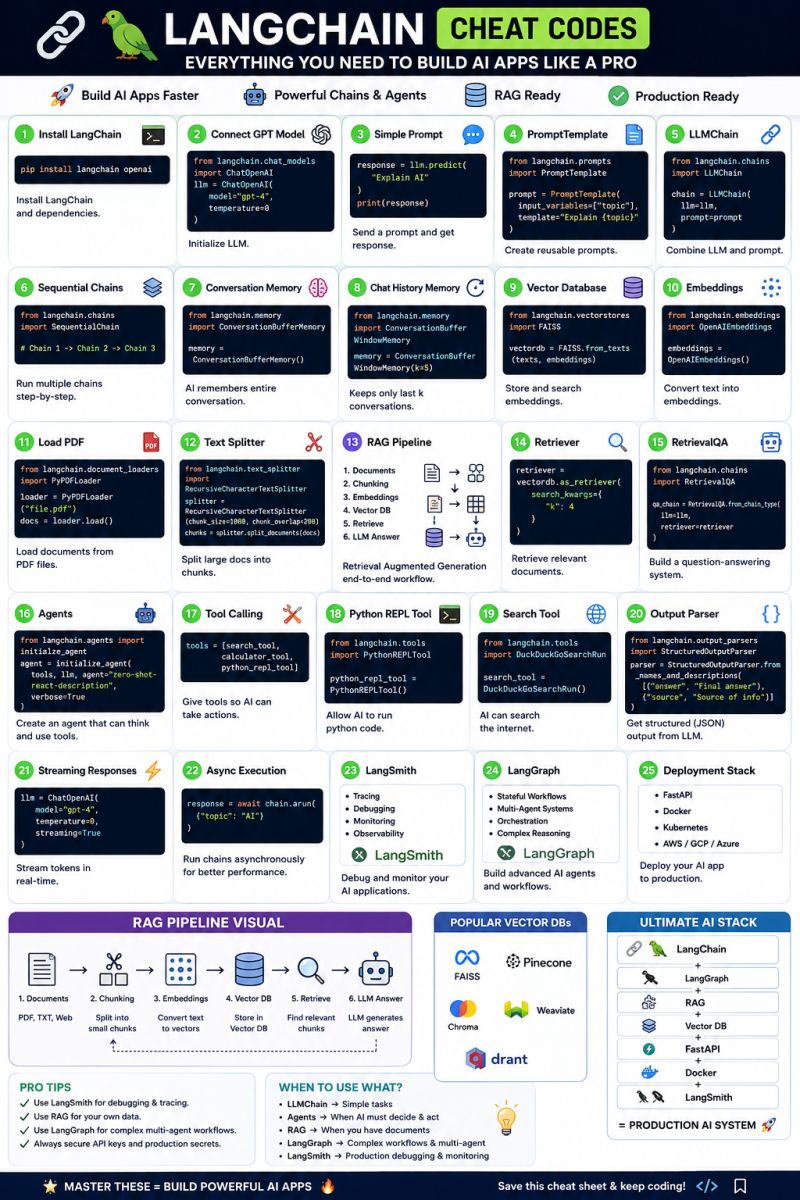